In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("data/loan_data_raw.csv")

In [3]:
# This counts exactly identical rows
df.duplicated().sum()

0

In [4]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [5]:
df['person_education'].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

In [6]:
df['person_home_ownership'].unique() 

array(['RENT', 'OWN', 'MORTGAGE', 'OTHER'], dtype=object)

In [7]:
df['loan_intent'].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

In [8]:
# 1. Create a cleaned copy for age and experience
df_clean = df[(df['person_age'] < 100) & (df['person_emp_exp'] < 60)]

# 2. Print how many rows were removed
print(f"Rows removed: {len(df) - len(df_clean)}")

# 3. Update the main dataframe
df = df_clean

Rows removed: 10


In [9]:
df['loan_status'].value_counts()

loan_status
0    34990
1    10000
Name: count, dtype: int64

In [10]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44990.000000,4.499000e+04,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000,44990.000000
mean,27.744543,7.990883e+04,5.390465,9583.297888,11.006510,0.139737,5.865259,632.578329,0.222272
std,5.890563,6.332359e+04,5.906165,6314.982527,2.979037,0.087208,3.874023,50.394327,0.415777
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719575e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704550e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577700e+04,8.000000,12237.750000,12.990000,0.190000,8.000000,670.000000,0.000000
max,78.000000,2.448661e+06,58.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


In [11]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_17136\1595878347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_intent', order=df['loan_intent'].value_counts().index, palette='viridis')


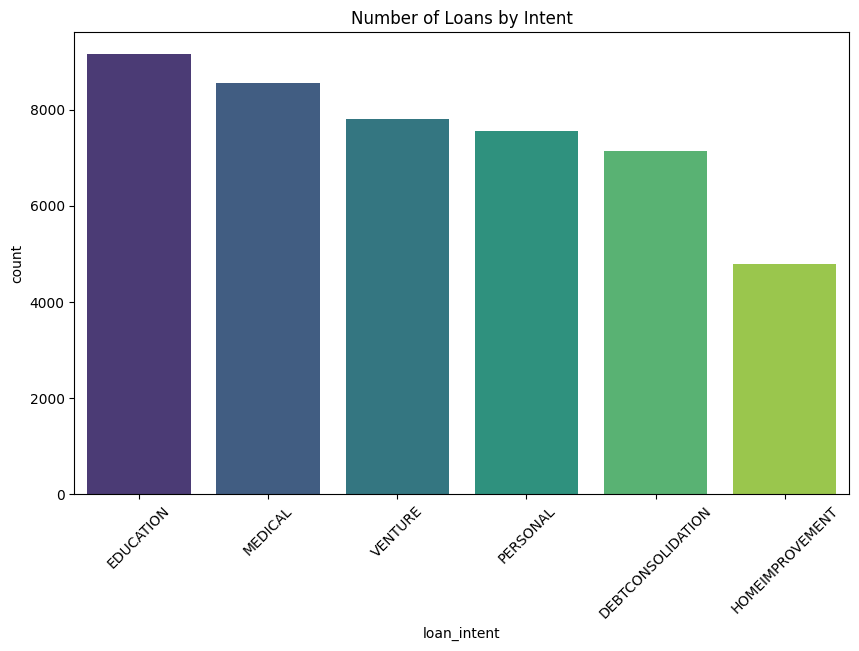

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='loan_intent', order=df['loan_intent'].value_counts().index, palette='viridis')
plt.title('Number of Loans by Intent')
plt.xticks(rotation=45)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_17136\358353074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='person_home_ownership', order=df['person_home_ownership'].value_counts().index, palette='viridis')


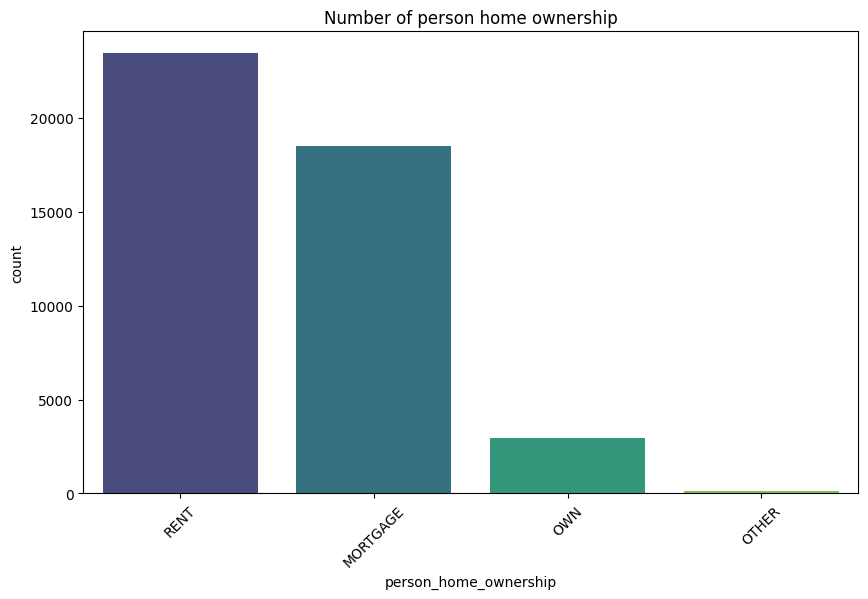

In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='person_home_ownership', order=df['person_home_ownership'].value_counts().index, palette='viridis')
plt.title('Number of person home ownership')
plt.xticks(rotation=45)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_17136\3512284799.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='person_education', order=df['person_education'].value_counts().index, palette='viridis')


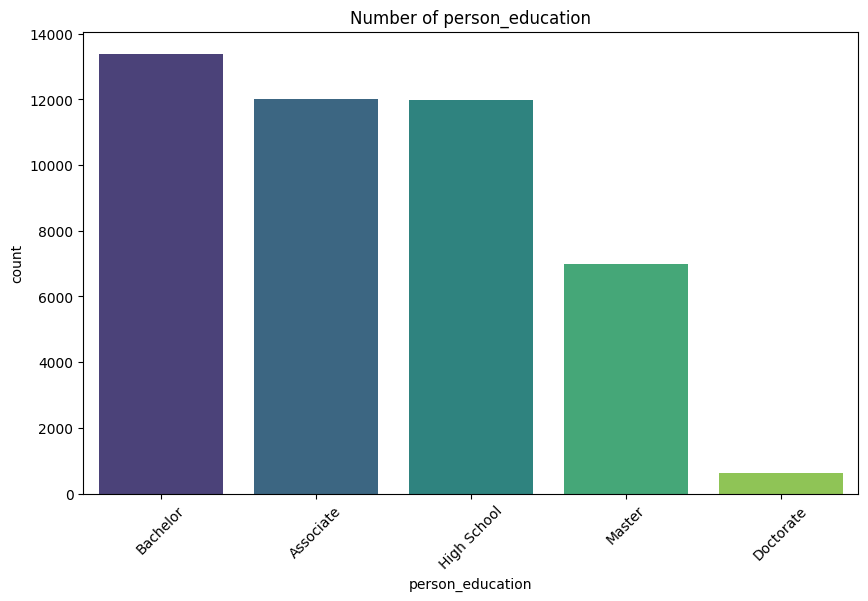

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='person_education', order=df['person_education'].value_counts().index, palette='viridis')
plt.title('Number of person_education')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Select the categorical columns you want to encode
cols_to_encode = ['person_education', 'person_home_ownership', 'loan_intent', 'person_gender', 'previous_loan_defaults_on_file']

# drop_first=True helps avoid the "dummy variable trap" (multicollinearity)
df1 = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# Preview the new columns
df1.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender_male,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,False,...,False,False,True,False,False,False,True,False,False,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,False,...,False,True,False,True,False,False,False,False,False,True
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,False,...,False,False,False,False,False,True,False,False,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,True,...,False,False,True,False,False,True,False,False,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,False,...,False,False,True,False,False,True,False,False,True,False


In [16]:
df1

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender_male,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,False,...,False,False,True,False,False,False,True,False,False,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,False,...,False,True,False,True,False,False,False,False,False,True
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,False,...,False,False,False,False,False,True,False,False,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,True,...,False,False,True,False,False,True,False,False,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,False,...,False,False,True,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1,False,...,False,False,True,False,False,True,False,False,True,False
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,1,False,...,False,False,True,False,True,False,False,False,False,False
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1,False,...,False,False,True,False,False,False,False,False,True,False
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1,True,...,False,False,True,True,False,False,False,False,True,False


In [17]:
# Select the categorical columns
cols_to_encode = ['person_education', 'person_home_ownership', 'loan_intent', 'person_gender', 'previous_loan_defaults_on_file']

# Add dtype=int to force 1 and 0 instead of True and False
df1 = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

# View the result
df1.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_education_Bachelor,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender_male,previous_loan_defaults_on_file_Yes
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,0,...,0,0,1,0,0,0,1,0,0,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,0,...,0,1,0,1,0,0,0,0,0,1
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,...,0,0,0,0,0,1,0,0,0,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,1,...,0,0,1,0,0,1,0,0,0,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,0,...,0,0,1,0,0,1,0,0,1,0


In [18]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df1.drop('loan_status', axis=1)
y = df1['loan_status']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 35992
Testing set size: 8998


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      6999
           1       0.90      0.75      0.82      1999

    accuracy                           0.93      8998
   macro avg       0.92      0.86      0.89      8998
weighted avg       0.93      0.93      0.92      8998



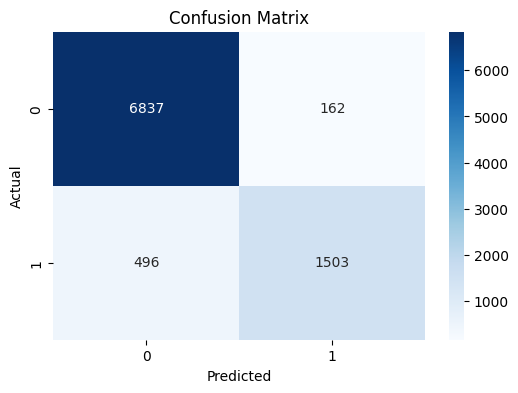

In [20]:
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualize the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# Get probability predictions (needed for AUC and Log Loss)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
loss = log_loss(y_test, y_prob)

print(f"Accuracy Score: {acc:.4f}")
print(f"ROC-AUC Score:  {auc:.4f}")
print(f"Log Loss:       {loss:.4f}")

Accuracy Score: 0.9269
ROC-AUC Score:  0.9729
Log Loss:       0.1737


In [22]:
# Optional experiment to see "True" predictive power without interest rates
X_no_rate = X.drop('loan_int_rate', axis=1)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_rate, y, test_size=0.2, random_state=42)

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train2, y_train2)
print(f"AUC without Interest Rate: {roc_auc_score(y_test2, model2.predict_proba(X_test2)[:, 1]):.4f}")

AUC without Interest Rate: 0.9523


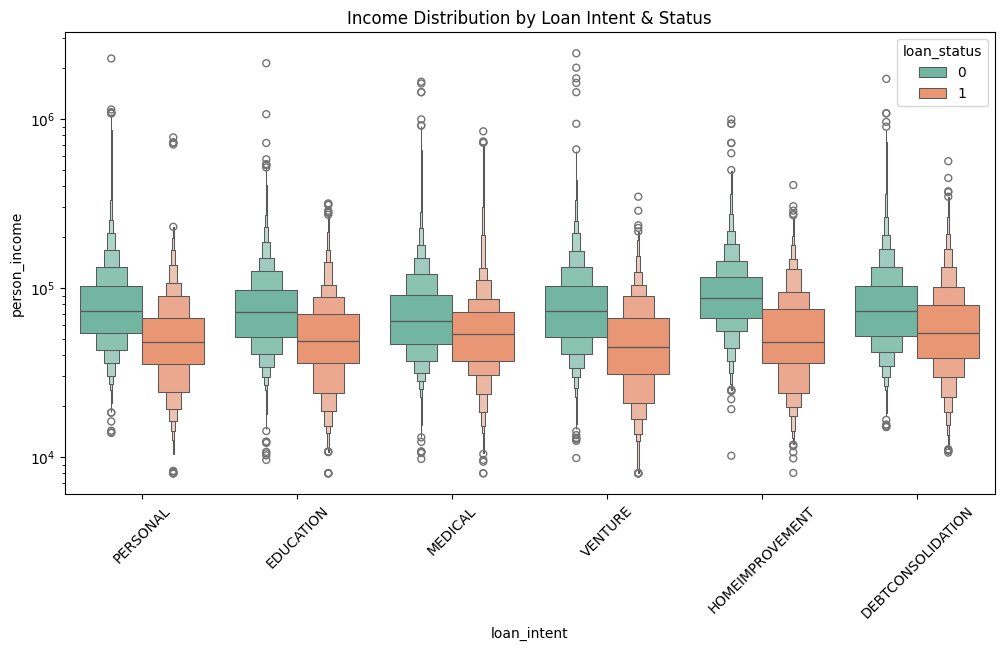

In [23]:
plt.figure(figsize=(12, 6))
sns.boxenplot(data=df_clean, x='loan_intent', y='person_income', hue='loan_status', palette='Set2')
plt.yscale('log') # Using log scale because income has a wide range
plt.title('Income Distribution by Loan Intent & Status')
plt.xticks(rotation=45)
plt.show()

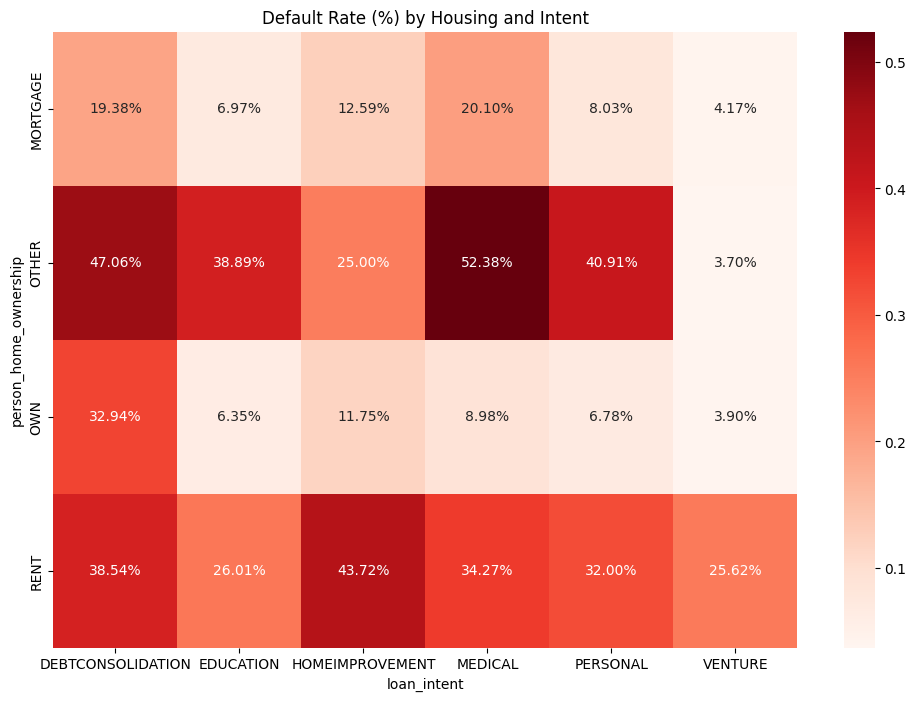

In [24]:
# Create a pivot table of default rates
pivot_df = df_clean.pivot_table(index='person_home_ownership', 
                                columns='loan_intent', 
                                values='loan_status', 
                                aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, cmap='Reds', fmt='.2%')
plt.title('Default Rate (%) by Housing and Intent')
plt.show()

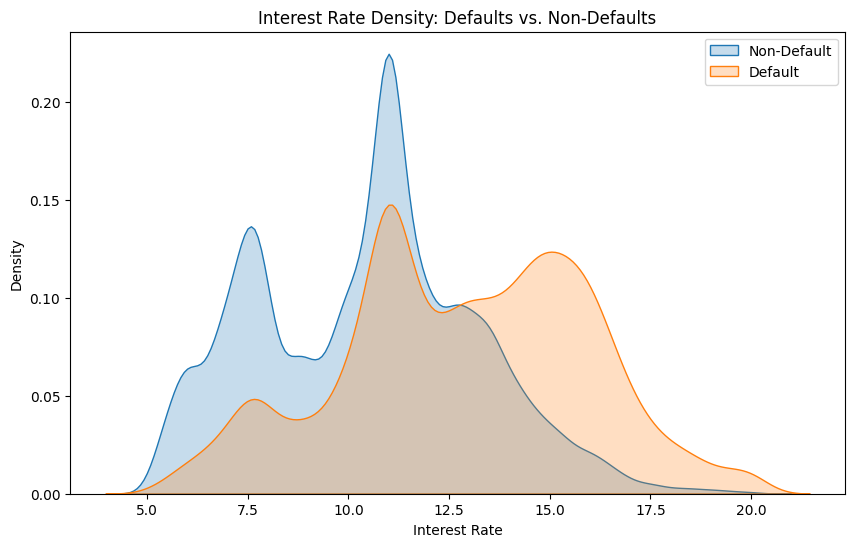

In [25]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_clean[df_clean['loan_status'] == 0]['loan_int_rate'], label='Non-Default', fill=True)
sns.kdeplot(df_clean[df_clean['loan_status'] == 1]['loan_int_rate'], label='Default', fill=True)
plt.title('Interest Rate Density: Defaults vs. Non-Defaults')
plt.xlabel('Interest Rate')
plt.legend()
plt.show()

 Data Insights & Exploratory Analysis
Based on the visual analysis of the dataset:
•	Loan Intent: The highest volume of loan applications are for Education, followed closely by Medical and Venture purposes.
•	Home Ownership: A significant portion of the applicant pool consists of individuals who Rent or have a Mortgage, which are key factors in determining financial stability.
•	Education Levels: The data shows a diverse range of educational backgrounds, which was encoded to help the model understand the correlation between education and repayment reliability.
